<a href="https://colab.research.google.com/github/vadim-vic/Causal-Inference/blob/main/code_sandbox/sandbox_neural_ODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install torchdiffeq


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint  # or odeint_adjoint for adjoint method

# ---------- Define the ODE function ----------
class ODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, dim),
        )
        # weight init (optional)
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, 0.)

    def forward(self, t, x):
        # note: solver passes (t, x)
        return self.net(x)

# ---------- ODEBlock integrates the ODE from t0 -> t1 ----------
class ODEBlock(nn.Module):
    def __init__(self, odefunc, tol=1e-3):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0.0, 1.0])  # integrate from 0 to 1
        self.tol = tol

    def forward(self, x):
        # odeint expects shape (time, batch, dim) if x is (batch, dim)
        self.integration_time = self.integration_time.type_as(x)
        out = odeint(self.odefunc, x, self.integration_time, rtol=self.tol, atol=self.tol)
        return out[1]  # return state at t=1

# ---------- Full model: initial linear layer -> ODEBlock -> classifier ----------
class ODEClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_classes):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        self.odefunc = ODEFunc(hidden_dim)
        self.odeblock = ODEBlock(self.odefunc, tol=1e-3)
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        h0 = torch.tanh(self.fc_in(x))
        h1 = self.odeblock(h0)
        out = self.fc_out(h1)
        return out

# ---------- Toy training loop (assumes you have toy data x_train, y_train) ----------
def train(model, x_train, y_train, epochs=100, batch_size=128, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    dataset = torch.utils.data.TensorDataset(x_train, y_train)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg = total_loss / len(dataset)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:03d}: loss = {avg:.4f}")

# ---------- Example: create synthetic 2D dataset ----------
if __name__ == "__main__":
    import sklearn.datasets as ds
    X, y = ds.make_moons(n_samples=1000, noise=0.1)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    model = ODEClassifier(input_dim=2, hidden_dim=64, n_classes=2)
    train(model, X, y, epochs=100, batch_size=128, lr=1e-3)

Epoch 010: loss = 0.0269
Epoch 020: loss = 0.0040
Epoch 030: loss = 0.0004
Epoch 040: loss = 0.0001
Epoch 050: loss = 0.0001
Epoch 060: loss = 0.0000
Epoch 070: loss = 0.0000
Epoch 080: loss = 0.0000
Epoch 090: loss = 0.0000
Epoch 100: loss = 0.0000


Epoch 020: loss = 0.0016
Epoch 040: loss = 0.0006
Epoch 060: loss = 0.0002
Epoch 080: loss = 0.0001
Epoch 100: loss = 0.0000
Epoch 120: loss = 0.0000
Epoch 140: loss = 0.0000
Epoch 160: loss = 0.0000
Epoch 180: loss = 0.0000
Epoch 200: loss = 0.0000


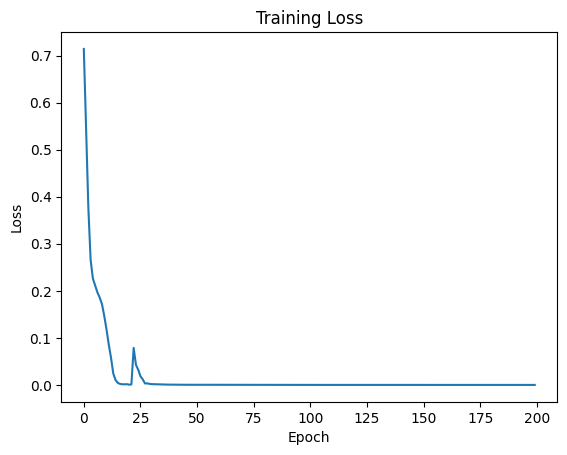

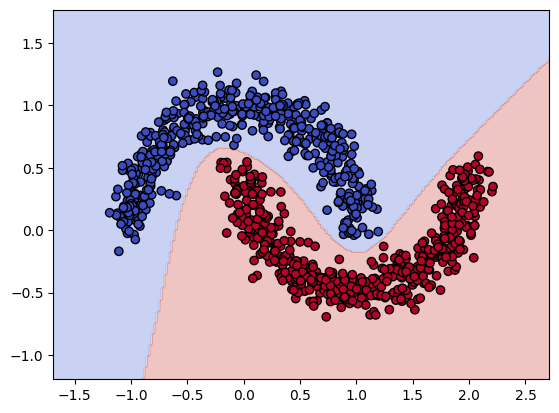

In [ ]:
# Neural ODE Example on 2D "moons" dataset
# =========================================
# Requires: pip install torchdiffeq matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from torchdiffeq import odeint

# ---------- Define ODE function ----------
class ODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, dim),
        )
        # init
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, 0.)

    def forward(self, t, x):
        return self.net(x)

# ---------- ODE Block ----------
class ODEBlock(nn.Module):
    def __init__(self, odefunc, tol=1e-3):
        super().__init__()
        self.odefunc = odefunc
        self.integration_time = torch.tensor([0.0, 1.0])
        self.tol = tol

    def forward(self, x):
        self.integration_time = self.integration_time.type_as(x)
        out = odeint(self.odefunc, x, self.integration_time, rtol=self.tol, atol=self.tol)
        return out[1]  # final state

# ---------- Full model ----------
class ODEClassifier(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, n_classes=2):
        super().__init__()
        self.fc_in = nn.Linear(input_dim, hidden_dim)
        self.odefunc = ODEFunc(hidden_dim)
        self.odeblock = ODEBlock(self.odefunc)
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        h0 = torch.tanh(self.fc_in(x))
        h1 = self.odeblock(h0)
        return self.fc_out(h1)

# ---------- Training utility ----------
def train(model, x_train, y_train, epochs=200, batch_size=128, lr=1e-3, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    dataset = torch.utils.data.TensorDataset(x_train, y_train)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    losses = []
    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg = total_loss / len(dataset)
        losses.append(avg)
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d}: loss = {avg:.4f}")
    return losses

# ---------- Visualization ----------
def plot_decision_boundary(model, X, y, device='cpu'):
    model.eval()
    # grid
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing="xy"
    )
    grid = torch.cat([xx.reshape(-1,1), yy.reshape(-1,1)], dim=1).to(device)
    with torch.no_grad():
        logits = model(grid)
        preds = logits.argmax(1).cpu().numpy()
    plt.contourf(xx, yy, preds.reshape(xx.shape), alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k")
    plt.show()

# ---------- Main ----------
if __name__ == "__main__":
    # dataset
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = torch.tensor(X, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.long)

    model = ODEClassifier()
    losses = train(model, X, y, epochs=200, batch_size=128, lr=1e-3)

    # plot loss curve
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

    # plot decision boundary
    plot_decision_boundary(model, X.numpy(), y.numpy())
